# Neuronpedia Attribution Graph Corpus — Demo

This notebook demonstrates the **Neuronpedia Attribution Graph Dataset** for `gemma-2-2b`.

**What this dataset contains:**
- 200 unique attribution graphs across 8 domains (antonym, arithmetic, code_completion, country_capital, multi_hop_reasoning, rhyme, sentiment, translation)
- Each record includes: input prompt, JSON-encoded DAG with 841–1876 nodes, correctness annotations, difficulty labels, and full graph metadata
- Merged from iter2 (140 graphs) and iter3 (60 new graphs)

**This demo loads a mini subset (8 records, 1 per domain)** and performs basic graph analysis including node/edge statistics, domain distributions, and structural properties.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# networkx — NOT pre-installed on Colab, always install
# 3.6.1 on Colab (Python 3.12), 3.4.2 on Python 3.10
_pip('networkx>=3.4')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
from collections import Counter

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

Load the mini demo dataset (8 graphs, 1 per domain) from GitHub or local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/dataset_iter3_scale_neuronped/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} attribution graphs")
print(f"Model: {data['metadata']['model']}")
print(f"Domains: {sorted(set(ex['metadata_fold'] for ex in examples))}")

Loaded 8 attribution graphs
Model: gemma-2-2b
Domains: ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'rhyme', 'sentiment', 'translation']


## Configuration

Tunable parameters for the analysis. These are set to minimal values for fast demo execution.

In [5]:
# Number of examples to analyze (max = len(examples))
N_SAMPLES = 8  # Full dataset: 200

# Max nodes to use when building NetworkX graph (for speed)
MAX_NODES_FOR_GRAPH = 15  # Full dataset: all nodes (841-1876)

# Max edges to use when building NetworkX graph
MAX_EDGES_FOR_GRAPH = 30  # Full dataset: all edges

## Parse Graphs and Extract Metadata

Parse each example's JSON-encoded DAG and collect structural metadata (node count, edge count, density, correctness, difficulty).

In [6]:
selected = examples[:N_SAMPLES]

records = []
graphs = []

for ex in selected:
    # Parse the JSON-encoded graph
    graph_data = json.loads(ex["output"])
    nodes = graph_data.get("nodes", [])[:MAX_NODES_FOR_GRAPH]
    edges = graph_data.get("edges", [])[:MAX_EDGES_FOR_GRAPH]

    # Build NetworkX DiGraph
    G = nx.DiGraph()
    for node in nodes:
        G.add_node(node["node_id"], **{k: v for k, v in node.items() if k != "node_id"})
    for edge in edges:
        if edge.get("source") in G.nodes and edge.get("target") in G.nodes:
            G.add_edge(edge["source"], edge["target"], weight=edge.get("weight", 1.0))

    graphs.append(G)

    records.append({
        "domain": ex["metadata_fold"],
        "input": ex["input"],
        "n_nodes": ex["metadata_n_nodes"],
        "n_edges": ex["metadata_n_edges"],
        "density": ex["metadata_density"],
        "is_dag": ex["metadata_is_dag"],
        "correct": ex["metadata_model_correct"],
        "difficulty": ex["metadata_difficulty"],
        "expected_answer": ex["metadata_expected_answer"],
        "provenance": ex["metadata_provenance"],
        "slug": ex["metadata_slug"],
    })

df = pd.DataFrame(records)
print(f"Parsed {len(records)} graphs successfully")
print(f"Built {len(graphs)} NetworkX DiGraphs")
df

Parsed 8 graphs successfully
Built 8 NetworkX DiGraphs


,domain,input,n_nodes,n_edges,density,is_dag,correct,difficulty,expected_answer,provenance,slug
0,antonym,The opposite of bright is,1000,37080,0.037117,True,false,easy,dim,iter3,m5-antonym-019-a39bd921
1,arithmetic,12 + 19 =,1027,39597,0.037579,True,true,easy,31,iter2,m4-arithmetic-007-8883759f
2,code_completion,def absolute(x):\n return,1270,52981,0.032874,True,true,easy,abs(x),iter2,m4-code_completion-005-96098955
3,country_capital,The capital of Argentina is,1076,50545,0.043698,True,true,easy,Buenos Aires,iter2,m4-country_capital-012-9797caad
4,multi_hop_reasoning,"If A is faster than B and B is faster than C, ...",1654,53173,0.019448,True,true,easy,faster than C,iter2,m4-multi_hop_reasoning-004-b01c4a9a
5,rhyme,The bat in the hat found a,1385,54472,0.028418,True,unknown,easy,multiple_valid,iter2,m4-rhyme-013-d2bb30c1
6,sentiment,This movie was amazing. The sentiment is,1512,85371,0.037368,True,true,easy,positive,iter2,m4-sentiment-005-9a5b6375
7,translation,The French word for book is,1179,55365,0.039864,True,true,easy,livre,iter2,m4-translation-003-e0e4b911


## Graph Structural Analysis

Validate DAG properties and compute basic graph statistics for each attribution graph.

In [7]:
# Validate DAG property and compute stats on the (truncated) demo graphs
graph_stats = []
for i, (G, rec) in enumerate(zip(graphs, records)):
    is_dag = nx.is_directed_acyclic_graph(G)
    n_components = nx.number_weakly_connected_components(G)
    longest_path = nx.dag_longest_path_length(G) if is_dag and len(G) > 0 else 0
    
    # Feature type distribution
    feat_types = Counter(d.get("feature_type", "unknown") for _, d in G.nodes(data=True))
    
    graph_stats.append({
        "domain": rec["domain"],
        "demo_nodes": G.number_of_nodes(),
        "demo_edges": G.number_of_edges(),
        "full_nodes": rec["n_nodes"],
        "full_edges": rec["n_edges"],
        "is_dag": is_dag,
        "n_components": n_components,
        "longest_path": longest_path,
        "feature_types": dict(feat_types),
    })

stats_df = pd.DataFrame(graph_stats)
print("Graph structural statistics (demo subset):")
print(stats_df[["domain", "demo_nodes", "demo_edges", "full_nodes", "full_edges", "is_dag", "longest_path"]].to_string(index=False))

Graph structural statistics (demo subset):
             domain  demo_nodes  demo_edges  full_nodes  full_edges  is_dag  longest_path
            antonym          15          28        1000       37080    True        4.7778
         arithmetic          15          25        1027       39597    True        3.5145
    code_completion          15          19        1270       52981    True        2.5449
    country_capital          15          25        1076       50545    True        3.0879
multi_hop_reasoning          15          30        1654       53173    True        5.0769
              rhyme          15          26        1385       54472    True        4.8890
          sentiment          15          26        1512       85371    True        3.6606
        translation          15          23        1179       55365    True        4.9438


## Dataset Summary

Print key aggregate statistics: correctness distribution, difficulty distribution, and per-domain node/edge averages.

In [8]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total graphs: {len(df)}")
print(f"Model: {data['metadata']['model']}")
print(f"Domains: {sorted(df['domain'].unique())}")
print()

# Correctness distribution
print("Correctness distribution:")
for val, cnt in df["correct"].value_counts().items():
    print(f"  {val}: {cnt}")
print()

# Difficulty distribution
print("Difficulty distribution:")
for val, cnt in df["difficulty"].value_counts().items():
    print(f"  {val}: {cnt}")
print()

# Per-domain stats
print("Per-domain node/edge statistics:")
domain_stats = df.groupby("domain").agg(
    avg_nodes=("n_nodes", "mean"),
    avg_edges=("n_edges", "mean"),
    avg_density=("density", "mean"),
).round(2)
print(domain_stats.to_string())

DATASET SUMMARY
Total graphs: 8
Model: gemma-2-2b
Domains: ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'rhyme', 'sentiment', 'translation']

Correctness distribution:
  true: 6
  false: 1
  unknown: 1

Difficulty distribution:
  easy: 8

Per-domain node/edge statistics:
                     avg_nodes  avg_edges  avg_density
domain                                                
antonym                 1000.0    37080.0         0.04
arithmetic              1027.0    39597.0         0.04
code_completion         1270.0    52981.0         0.03
country_capital         1076.0    50545.0         0.04
multi_hop_reasoning     1654.0    53173.0         0.02
rhyme                   1385.0    54472.0         0.03
sentiment               1512.0    85371.0         0.04
translation             1179.0    55365.0         0.04


## Visualization

Plot node counts, edge counts, and graph density across domains. Also visualize one example attribution graph.

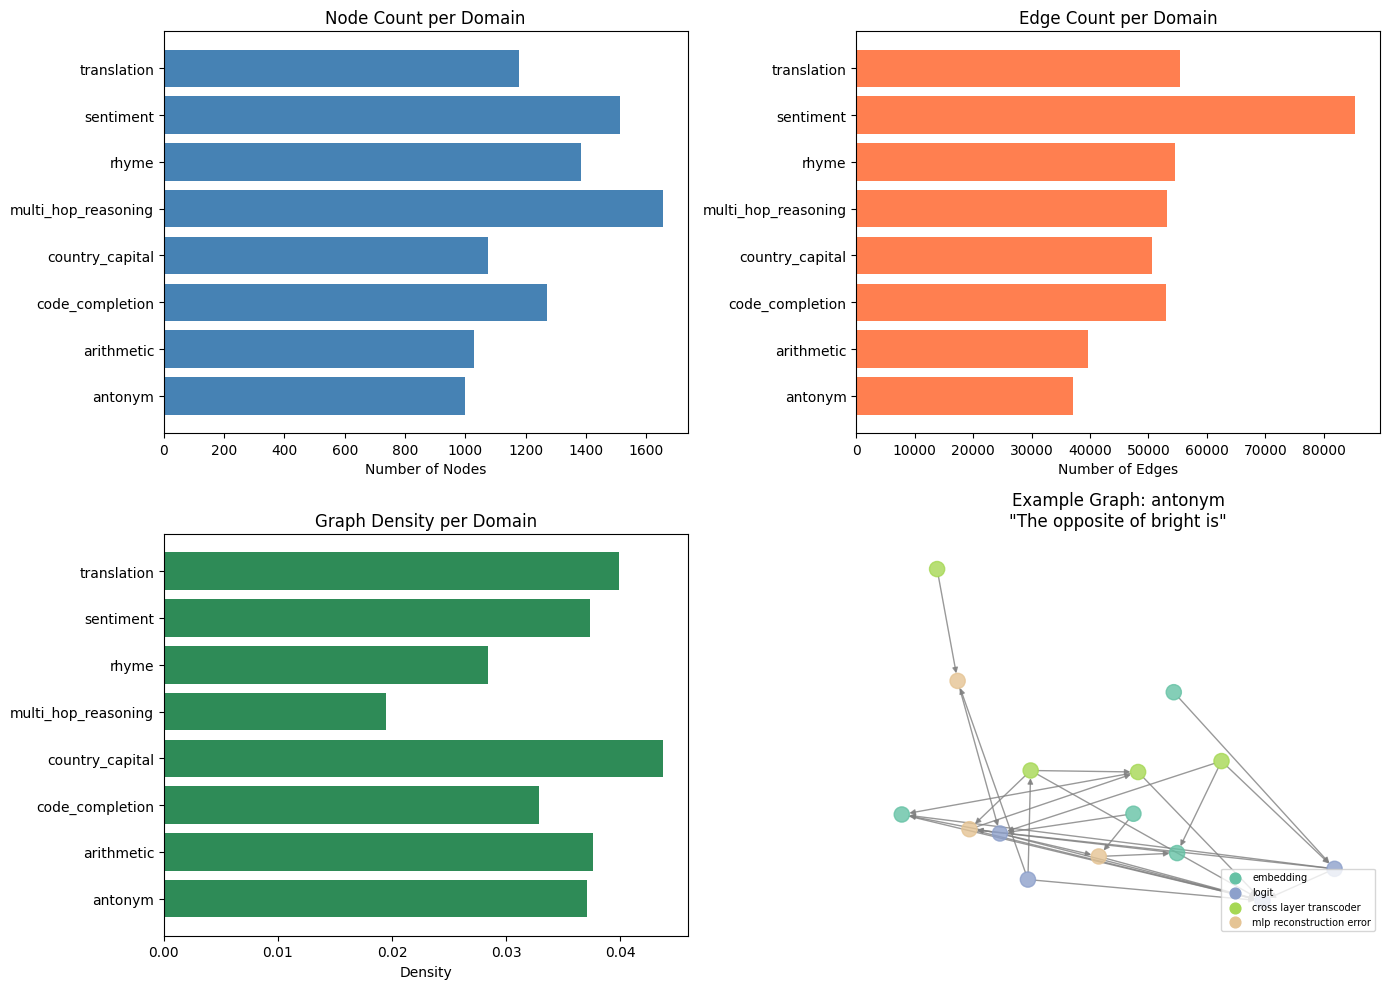

Saved visualization to attribution_graph_analysis.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Node counts per domain
ax = axes[0, 0]
ax.barh(df["domain"], df["n_nodes"], color="steelblue")
ax.set_xlabel("Number of Nodes")
ax.set_title("Node Count per Domain")

# 2. Edge counts per domain
ax = axes[0, 1]
ax.barh(df["domain"], df["n_edges"], color="coral")
ax.set_xlabel("Number of Edges")
ax.set_title("Edge Count per Domain")

# 3. Graph density per domain
ax = axes[1, 0]
ax.barh(df["domain"], df["density"], color="seagreen")
ax.set_xlabel("Density")
ax.set_title("Graph Density per Domain")

# 4. Example graph visualization (first graph)
ax = axes[1, 1]
G_example = graphs[0]
if len(G_example) > 0:
    pos = nx.spring_layout(G_example, seed=42)
    # Color nodes by feature type
    feat_types_list = [d.get("feature_type", "unknown") for _, d in G_example.nodes(data=True)]
    unique_types = list(set(feat_types_list))
    color_map = {t: plt.cm.Set2(i / max(len(unique_types), 1)) for i, t in enumerate(unique_types)}
    node_colors = [color_map[t] for t in feat_types_list]
    
    nx.draw(G_example, pos, ax=ax, node_size=120, node_color=node_colors,
            edge_color="gray", alpha=0.8, arrows=True, arrowsize=8,
            with_labels=False)
    ax.set_title(f"Example Graph: {records[0]['domain']}\n\"{records[0]['input']}\"")
    # Legend
    for t, c in color_map.items():
        ax.scatter([], [], c=[c], label=t, s=60)
    ax.legend(loc="lower right", fontsize=7)
else:
    ax.text(0.5, 0.5, "No graph to display", ha="center", va="center")
    ax.set_title("Example Graph")

plt.tight_layout()
plt.savefig("attribution_graph_analysis.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved visualization to attribution_graph_analysis.png")